SGD Final Weight : 0.008435159921646118
SGD Final Bias   : 2.6021413803100586

Momentum Final Weight : 0.0016813140828162432
Momentum Final Bias   : 2.9873154163360596

RMSprop Final Weight : -1.551661910070834e-08
RMSprop Final Bias   : 1.0581163167953491

Adam Final Weight : -0.0039003717247396708
Adam Final Bias   : 0.9375531673431396



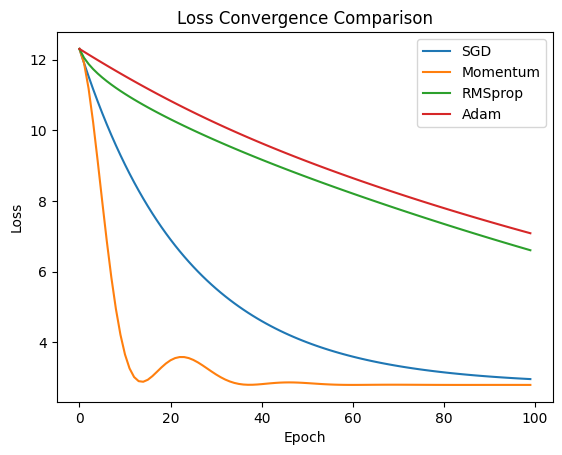

In [12]:
import torch
import matplotlib.pyplot as plt

# Dataset
X = torch.tensor([[-2.0], [-1.0], [0.0], [1.0], [2.0]])
Y = X**2 + 1

epochs = 100
lr = 0.01

# Function to Train
def train(optimizer):

    # Initial Weight and Bias
    w = torch.tensor([0.5])
    b = torch.tensor([0.0])

    # Variables for Optimizers
    velocity_w = torch.tensor([0.0])
    velocity_b = torch.tensor([0.0])

    cache_w = torch.tensor([0.0])
    cache_b = torch.tensor([0.0])

    m_w = torch.tensor([0.0])
    m_b = torch.tensor([0.0])

    v_w = torch.tensor([0.0])
    v_b = torch.tensor([0.0])

    loss_history = []

    for epoch in range(1, epochs + 1):

        # Forward Pass
        pred = X * w + b

        # Loss
        loss = torch.mean((pred - Y) ** 2)
        loss_history.append(loss.item())

        # Manual Gradients
        dw = (2 / len(X)) * torch.sum((pred - Y) * X)
        db = (2 / len(X)) * torch.sum(pred - Y)

        #SGD
        if optimizer == "SGD":
            w = w - lr * dw
            b = b - lr * db

        #Momentum
        elif optimizer == "Momentum":
            momentum = 0.9

            velocity_w = momentum * velocity_w + dw
            velocity_b = momentum * velocity_b + db

            w = w - lr * velocity_w
            b = b - lr * velocity_b

        # RMSprop
        elif optimizer == "RMSprop":
            beta = 0.9

            cache_w = beta * cache_w + (1 - beta) * dw**2
            cache_b = beta * cache_b + (1 - beta) * db**2

            w = w - lr * dw / (torch.sqrt(cache_w) + 1e-8)
            b = b - lr * db / (torch.sqrt(cache_b) + 1e-8)

        # Adam
        elif optimizer == "Adam":

            beta1 = 0.9
            beta2 = 0.999

            m_w = beta1 * m_w + (1 - beta1) * dw
            m_b = beta1 * m_b + (1 - beta1) * db

            v_w = beta2 * v_w + (1 - beta2) * dw**2
            v_b = beta2 * v_b + (1 - beta2) * db**2

            # Bias Correction
            m_w_hat = m_w / (1 - beta1**epoch)
            m_b_hat = m_b / (1 - beta1**epoch)

            v_w_hat = v_w / (1 - beta2**epoch)
            v_b_hat = v_b / (1 - beta2**epoch)

            w = w - lr * m_w_hat / (torch.sqrt(v_w_hat) + 1e-8)
            b = b - lr * m_b_hat / (torch.sqrt(v_b_hat) + 1e-8)

    print(f"{optimizer} Final Weight :", w.item())
    print(f"{optimizer} Final Bias   :", b.item())
    print()

    return loss_history


# Train with All Optimizers
sgd_loss = train("SGD")
momentum_loss = train("Momentum")
rmsprop_loss = train("RMSprop")
adam_loss = train("Adam")


# Plot Comparison
plt.plot(sgd_loss, label="SGD")
plt.plot(momentum_loss, label="Momentum")
plt.plot(rmsprop_loss, label="RMSprop")
plt.plot(adam_loss, label="Adam")

plt.title("Loss Convergence Comparison")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()